Nick and Dillan

In [2]:
#importing all necessary libraries for PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#https://www.kaggle.com/datasets/vishardmehta/diabetes-risk-prediction-dataset

In [3]:
#Importing diabetes dataset and showing first 5 rows
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("diabetes_risk_dataset.csv")
df.head()

Saving diabetes_risk_dataset.csv to diabetes_risk_dataset.csv


,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [4]:
df.isnull().sum() #Checking if there are any null values

,0
Patient_ID,0
age,0
gender,0
bmi,0
blood_pressure,0
fasting_glucose_level,0
insulin_level,0
HbA1c_level,0
cholesterol_level,0
triglycerides_level,0


In [5]:
#Dropping family history and physical activity because they are strings and not important to the Algorithm
df.drop("family_history_diabetes", axis=1, inplace=True)
df.drop("physical_activity_level", axis=1, inplace=True)

In [6]:
#This is also irrelevant to the algorithm
df.drop("gender", axis=1, inplace=True)
df.drop("age", axis=1, inplace=True)

In [7]:
df.head() #Checking to see if the columns got dropped correctly

,Patient_ID,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,33.8,154,93,12.1,5.2,242,194,2169,78.4,8.1,4,101.1,52.3,Prediabetes
1,2,19.2,123,94,4.6,5.4,212,76,1881,16.5,6.6,3,60.0,3.7,Low Risk
2,3,33.7,141,150,10.8,6.9,247,221,2811,147.9,6.7,10,114.7,87.3,High Risk
3,4,32.8,140,145,11.6,6.8,195,193,2826,98.3,4.4,9,96.6,76.1,High Risk
4,5,33.7,165,90,18.3,5.6,217,170,2610,65.8,9.1,5,107.4,47.7,Prediabetes


In [8]:
print("Dataset shape:", df.shape) #Just an extra feature to sheck the shape
print(df.head())

Dataset shape: (6000, 15)
   Patient_ID   bmi  blood_pressure  fasting_glucose_level  insulin_level  \
0           1  33.8             154                     93           12.1   
1           2  19.2             123                     94            4.6   
2           3  33.7             141                    150           10.8   
3           4  32.8             140                    145           11.6   
4           5  33.7             165                     90           18.3   

   HbA1c_level  cholesterol_level  triglycerides_level  daily_calorie_intake  \
0          5.2                242                  194                  2169   
1          5.4                212                   76                  1881   
2          6.9                247                  221                  2811   
3          6.8                195                  193                  2826   
4          5.6                217                  170                  2610   

   sugar_intake_grams_per_day 

In [9]:
#Patient ID is excluded from the rest of the measurments, but it is not dropped from the table
features = [col for col in df.columns if col != 'Patient_ID' ]
print("\nfeautures ({}):".format(len(features)), features)
print("\nLabel counts:\n", df['Patient_ID'].value_counts().sort_index())


feautures (14): ['bmi', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'HbA1c_level', 'cholesterol_level', 'triglycerides_level', 'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours', 'stress_level', 'waist_circumference_cm', 'diabetes_risk_score', 'diabetes_risk_category']

Label counts:
 Patient_ID
1       1
2       1
3       1
4       1
5       1
       ..
5996    1
5997    1
5998    1
5999    1
6000    1
Name: count, Length: 6000, dtype: int64


In [10]:
#We need to keep the diabetes risk categeory but it is in string format
#We use the Label Encoder to format it from 0 to 2 or label into integers
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
label = le.fit_transform(df['diabetes_risk_category'])
label

array([2, 1, 0, ..., 1, 1, 0])

In [11]:
#We drop the original column because we do not need it anymore
#We bring it back but with the label encoder
df.drop("diabetes_risk_category", axis=1, inplace=True)
df["diabetes_risk_category"] = label
df

,Patient_ID,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,33.8,154,93,12.1,5.2,242,194,2169,78.4,8.1,4,101.1,52.3,2
1,2,19.2,123,94,4.6,5.4,212,76,1881,16.5,6.6,3,60.0,3.7,1
2,3,33.7,141,150,10.8,6.9,247,221,2811,147.9,6.7,10,114.7,87.3,0
3,4,32.8,140,145,11.6,6.8,195,193,2826,98.3,4.4,9,96.6,76.1,0
4,5,33.7,165,90,18.3,5.6,217,170,2610,65.8,9.1,5,107.4,47.7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,5996,21.8,158,89,6.3,5.3,198,132,1995,44.1,7.6,7,82.7,0.0,1
5996,5997,47.3,193,109,33.7,6.1,250,209,3401,61.4,5.3,10,150.0,100.0,0
5997,5998,31.0,139,90,15.1,5.3,190,164,3022,86.7,6.8,3,102.7,22.3,1
5998,5999,26.2,136,88,6.3,5.5,223,126,2311,28.2,8.4,5,90.6,3.9,1


In [12]:
#This sets each feature with a mean of 0 and a std of 1
#Printing out the mean and std, just to double check its correct
x = StandardScaler().fit_transform(df[features])

print("\nNormalized dat - Mean: {:.4f}, Std: {:.4}".format(np.mean(x), np.std(x)))


Normalized dat - Mean: 0.0000, Std: 1.0


In [13]:
#We are cutting down the dimensions from 15 to 2 to make it a 2d model
#The 2 components captures the greatest variance of the data
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)
pca_df=pd.DataFrame(principal_components, columns=['PC1', 'PC2'])

In [14]:
#shows how much variance is captured in each component and combines
print("\nExplained variance per component:")
print(" PC1: {:.1%} | PC2: {:.1%}".format(*pca.explained_variance_ratio_))
print(" Combined: {:.1%} of total varaince captured".format(
  sum(pca.explained_variance_ratio_)))


Explained variance per component:
 PC1: 55.4% | PC2: 11.2%
 Combined: 66.6% of total varaince captured


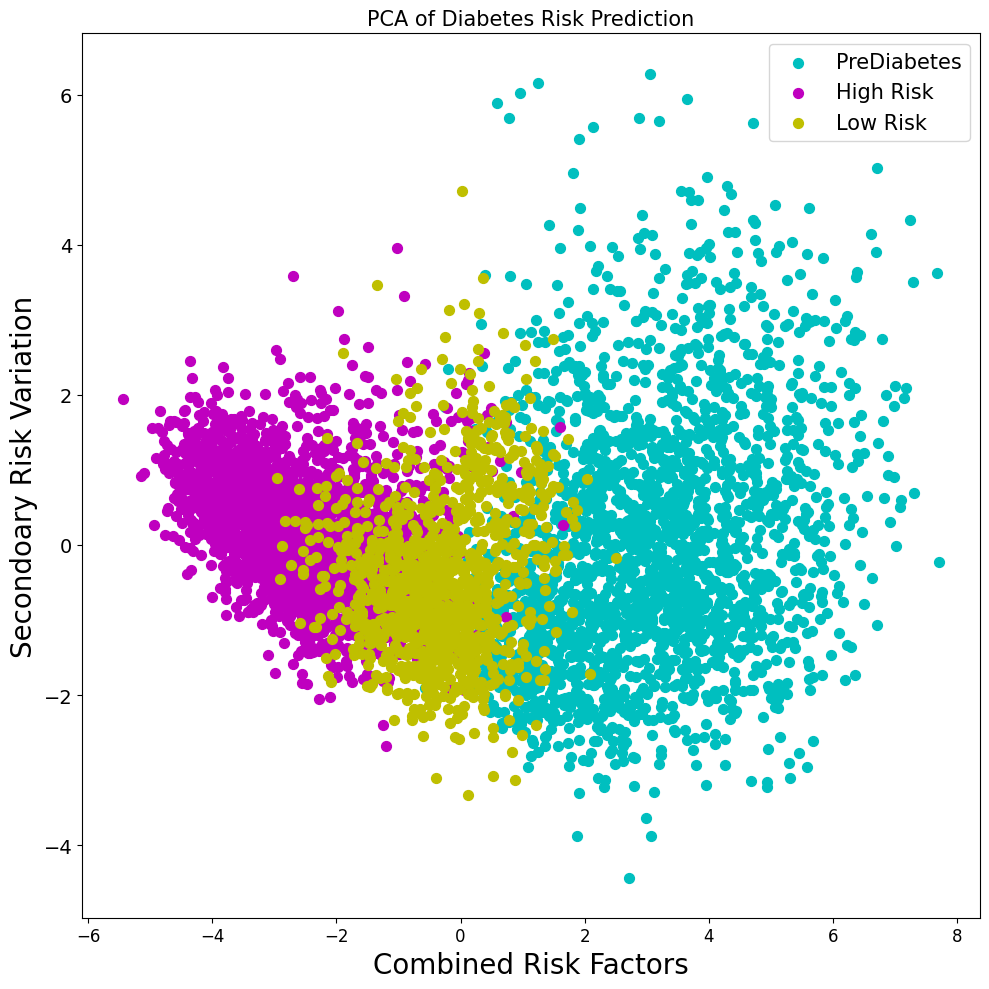


Plot saved as 'pca_diabetes.png'


In [16]:
#This shows the full table with labels, sizes, and data spread out on the graph
#It labels prediabetes, high risk, and low risk on the graph
plt.figure(figsize=(10, 10))
plt.xlabel('Combined Risk Factors', fontsize=20)
plt.ylabel('Secondoary Risk Variation', fontsize=20)
plt.title('PCA of Diabetes Risk Prediction', fontsize=15)
plt.xticks(fontsize=12); plt.yticks(fontsize=14)
colors ={0:('c', 'PreDiabetes'), 1: ('m', 'High Risk'), 2: ('y', 'Low Risk')}
for label, (color, name) in colors.items():
    mask = df['diabetes_risk_category'] == label
    plt.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                c=color, s=50, label=name)
plt.legend(prop={'size': 15})
plt.tight_layout()
plt.savefig('pca_diabetes.png', dpi=150)
plt.show()
print("\nPlot saved as 'pca_diabetes.png'")

In [ ]:
#There was no need of replacing null values because it contained none
#The only feature engineering we need was label encoder and standardizing the dataset.
#We decided to drop columns that were not needed. They were dropped because it would not make sense to label encode them; we did not want to throw the dataset off with irrelevant values.
#No need to reorganize the columns or hot encode.

We decided to focus on a diabtetes dataset with peoples health stats. These stats are regarding there blood pressure, bmi, insuline, cholestral level, etc. We wanted to combine all these stats and slim it down to best and most important data, so we decided to use this Principle Component Analysis algorithm. The algorithm captures all main 15 stats like some I already mentioned and it narrows it down to 2 stats. The algorithm seperates each stats to either group, it decides the best placement. In group one it captures only %55 of the dataset and the second group only capturing %11. Combined it only captures 66% of the data, which is enough for us. We wanted to show who already have prediabetes, low risk, and high risk of being diagnosed with diabetes. As you can see, it shows the ranges of both combined factors and the secondary risk factors.